# 📊 Evaluasi Batch OCR KTP — Bab IV Skripsi
**Project:** Implementasi Fitur Autofill Berbasis Tesseract OCR pada Sistem PMB UM Bandung

**Metrik:** Character Error Rate (CER) pada 50 sampel citra e-KTP

**Dataset:** 5 KTP fisik dummy × 10 variasi foto (angle & pencahayaan berbeda) = 50 foto

---

## 1️⃣ Install Dependencies & Mount Google Drive

In [ ]:
# Install Tesseract OCR engine + bahasa Indonesia
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr tesseract-ocr-ind

# Install Python packages
!pip install -q pytesseract opencv-python-headless python-Levenshtein openpyxl pandas

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('\n\u2705 Semua dependensi terinstall & Drive ter-mount!')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Semua dependensi terinstall & Drive ter-mount!


## 2️⃣ Konfigurasi Path

⚠️ **SESUAIKAN** path di bawah ini dengan lokasi folder dan file Anda di Google Drive.

In [ ]:
import os

# ============================================================
# SESUAIKAN PATH INI
# ============================================================
BASE_DIR       = '/content/drive/MyDrive/ktp_data'
DATASET_FOLDER = os.path.join(BASE_DIR, 'dataset_terbaru')      # Folder 50 foto .jpg
GT_CSV_PATH    = os.path.join(BASE_DIR, 'ground_truth.csv')  # Kunci jawaban
OUTPUT_XLSX    = os.path.join(BASE_DIR, 'hasil_evaluasi_bab4.xlsx')  # Output
# ============================================================

# Validasi path
assert os.path.isdir(DATASET_FOLDER), f'\u274c Folder tidak ditemukan: {DATASET_FOLDER}'
assert os.path.isfile(GT_CSV_PATH),   f'\u274c CSV tidak ditemukan: {GT_CSV_PATH}'

files = [f for f in os.listdir(DATASET_FOLDER) if f.lower().endswith(('.jpg','.jpeg','.png'))]
print(f'\u2705 Folder dataset: {len(files)} gambar ditemukan')
print(f'\u2705 Ground truth : {GT_CSV_PATH}')

✅ Folder dataset: 55 gambar ditemukan
✅ Ground truth : /content/drive/MyDrive/ktp_data/ground_truth.csv


## 3️⃣ Baca Ground Truth (Kunci Jawaban)

In [ ]:
import pandas as pd

df_gt = pd.read_csv(GT_CSV_PATH)

# Validasi kolom
for col in ['filename', 'true_nik', 'true_nama']:
    assert col in df_gt.columns, f"\u274c Kolom '{col}' tidak ada di CSV!"

# Pastikan NIK dibaca sebagai string
df_gt['true_nik']  = df_gt['true_nik'].astype(str).str.strip()
df_gt['true_nama'] = df_gt['true_nama'].astype(str).str.strip().str.upper()

print(f'\u2705 Total data ground truth: {len(df_gt)} baris\n')
df_gt.head(10)

✅ Total data ground truth: 50 baris



,filename,true_nik,true_nama,case_skenario
0,ktp1_foto01.jpg,3204012506980001,UJANG SURYADI,Jarak Dekat - Kertas HVS Putih
1,ktp1_foto02.jpg,3204012506980001,UJANG SURYADI,Jarak Dekat - Meja Kayu/Gelap
2,ktp1_foto03.jpg,3204012506980001,UJANG SURYADI,Jarak Sedang - Kertas HVS Putih
3,ktp1_foto04.jpg,3204012506980001,UJANG SURYADI,Jarak Sedang - Meja Kayu/Gelap
4,ktp1_foto05.jpg,3204012506980001,UJANG SURYADI,Pencahayaan Alami (Siang)
5,ktp1_foto06.jpg,3204012506980001,UJANG SURYADI,Pencahayaan Lampu LED (Malam)
6,ktp1_foto07.jpg,3204012506980001,UJANG SURYADI,Posisi KTP Cenderung Kiri Frame
7,ktp1_foto08.jpg,3204012506980001,UJANG SURYADI,Posisi KTP Cenderung Kanan Frame
8,ktp1_foto09.jpg,3204012506980001,UJANG SURYADI,Rasio Kamera 1:1 (Square)
9,ktp1_foto10.jpg,3204012506980001,UJANG SURYADI,Rasio Kamera 16:9 (Fullscreen)


## 4️⃣ Definisi Fungsi Preprocessing & OCR
Pipeline yang sama persis dengan backend Flask (`app.py`):

**Grayscale → CLAHE → Gaussian Blur → Otsu Binarization → Deskew → Tesseract → Regex**

```python
import re
import cv2
import numpy as np
import pytesseract

def preprocess_from_path(image_path):
    """Baca gambar dari path lalu jalankan pipeline preprocessing OpenCV."""
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f'Gagal membaca: {image_path}')

    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred  = cv2.GaussianBlur(enhanced, (3, 3), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary   = _deskew(binary)
    return binary


def _deskew(image):
    """Koreksi kemiringan teks."""
    coords = np.column_stack(np.where(image > 0))
    if len(coords) < 100: return image
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) < 0.5 or abs(angle) > 15: return image
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def extract_ocr(processed_image):
    """Jalankan Tesseract OCR lalu ekstrak NIK & Nama via Regex."""
    try:
        raw = pytesseract.image_to_string(processed_image, lang='ind+eng', config='--psm 6')
    except:
        try:   raw = pytesseract.image_to_string(processed_image, lang='ind', config='--psm 6')
        except: raw = pytesseract.image_to_string(processed_image, lang='eng', config='--psm 6')

    # --- NIK (16 digit) ---
    nik = ''
    m = re.search(r'NIK\s*[:\-]?\s*(\d[\d\s]{14,19}\d)', raw, re.IGNORECASE)
    if m:
        d = re.sub(r'\s', '', m.group(1))
        if len(d) >= 16: nik = d[:16]
    if not nik:
        f = re.findall(r'\b(\d{16})\b', raw)
        if f: nik = f[0]
    if not nik:
        for match in re.findall(r'(\d[\d\s]{14,19}\d)', raw):
            c = re.sub(r'\s', '', match)
            if len(c) >= 16: nik = c[:16]; break

    # --- Nama ---
    nama = ''
    nm = re.search(r'(?:^|\n)\s*Nama\s*[:\-]?\s*(.+)', raw, re.IGNORECASE)
    if nm:
        nama = re.sub(r"[^A-Za-z\s'.\,]", '', nm.group(1)).strip().upper()
    if not nama:
        skip = ['PROVINSI','KABUPATEN','KOTA','KELAMIN','ALAMAT','AGAMA','PEKERJAAN','STATUS','KEWARGANEGARAAN','BERLAKU','NIK']
        for line in raw.split('\n'):
            c = line.strip()
            if c.isupper() and len(c.split())>=2 and not re.search(r'\d',c) and len(c)>4:
                if not any(kw in c for kw in skip): nama = c; break

    return {'nik': nik, 'nama': nama, 'raw_text': raw}
```

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/ktp_data/dataset_terbaru/')[:5])

['ktp4_foto01.jpg', 'ktp4_foto03.jpg', 'ktp4_foto09.jpg', 'ktp4_foto10.jpg', 'ktp4_foto07.jpg']


In [ ]:
import re
import cv2
import numpy as np
import pytesseract


def preprocess_from_path(image_path):
    """Baca gambar dari path lalu jalankan pipeline preprocessing OpenCV."""
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f'Gagal membaca: {image_path}')

    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred  = cv2.GaussianBlur(enhanced, (3, 3), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary   = _deskew(binary)
    return binary


def _deskew(image):
    """Koreksi kemiringan teks."""
    coords = np.column_stack(np.where(image > 0))
    if len(coords) < 100: return image
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) < 0.5 or abs(angle) > 15: return image
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def extract_ocr(processed_image):
    """Jalankan Tesseract OCR lalu ekstrak NIK & Nama via Regex."""
    try:
        raw = pytesseract.image_to_string(processed_image, lang='ind+eng', config='--psm 6')
    except:
        try:   raw = pytesseract.image_to_string(processed_image, lang='ind', config='--psm 6')
        except: raw = pytesseract.image_to_string(processed_image, lang='eng', config='--psm 6')

    # --- NIK (16 digit) ---
    nik = ''
    m = re.search(r'NIK\s*[:\-]?\s*(\d[\d\s]{14,19}\d)', raw, re.IGNORECASE)
    if m:
        d = re.sub(r'\s', '', m.group(1))
        if len(d) >= 16: nik = d[:16]
    if not nik:
        f = re.findall(r'\b(\d{16})\b', raw)
        if f: nik = f[0]
    if not nik:
        for match in re.findall(r'(\d[\d\s]{14,19}\d)', raw):
            c = re.sub(r'\s', '', match)
            if len(c) >= 16: nik = c[:16]; break

    # --- Nama ---
    nama = ''
    nm = re.search(r'(?:^|\n)\s*Nama\s*[:\-]?\s*(.+)', raw, re.IGNORECASE)
    if nm:
        nama = re.sub(r"[^A-Za-z\s'.\,]", '', nm.group(1)).strip().upper()
    if not nama:
        skip = ['PROVINSI','KABUPATEN','KOTA','KELAMIN','ALAMAT','AGAMA','PEKERJAAN','STATUS','KEWARGANEGARAAN','BERLAKU','NIK']
        for line in raw.split('\n'):
            c = line.strip()
            if c.isupper() and len(c.split())>=2 and not re.search(r'\d',c) and len(c)>4:
                if not any(kw in c for kw in skip): nama = c; break

    return {'nik': nik, 'nama': nama, 'raw_text': raw}


print('\u2705 Fungsi preprocessing & OCR siap!')

✅ Fungsi preprocessing & OCR siap!


## 5️⃣ Fungsi Perhitungan CER (Character Error Rate)

$$CER = \frac{Levenshtein\_Distance(prediksi,\ referensi)}{jumlah\_karakter\_referensi}$$

In [ ]:
import Levenshtein

def hitung_cer(prediksi, referensi):
    """
    Menghitung Character Error Rate (CER).
    CER = 0.0 berarti sempurna (tidak ada kesalahan karakter).
    CER = 1.0 berarti 100% karakter salah.
    """
    pred = str(prediksi).strip().upper()
    ref  = str(referensi).strip().upper()
    if len(ref) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return round(Levenshtein.distance(pred, ref) / len(ref), 4)


# Quick test
print('Uji fungsi CER:')
print(f'  Identik        : {hitung_cer("UJANG", "UJANG")}')       # 0.0
print(f'  1 huruf salah  : {hitung_cer("UJAMG", "UJANG")}')       # 0.2
print(f'  Kosong vs ref  : {hitung_cer("", "UJANG")}')             # 1.0
print('\u2705 Fungsi CER siap!')

Uji fungsi CER:
  Identik        : 0.0
  1 huruf salah  : 0.2
  Kosong vs ref  : 1.0
✅ Fungsi CER siap!


## 6️⃣ Jalankan Evaluasi Batch (50 Gambar)
Loop seluruh gambar → preprocessing → OCR → bandingkan dengan ground truth → hitung CER

In [ ]:
import time

results = []
total   = len(df_gt)
t_start = time.time()

print(f'\U0001f680 Memulai evaluasi {total} gambar...\n')
print(f'{"No":<4} {"Filename":<22} {"CER_NIK":<10} {"CER_Nama":<10} {"Waktu":<8} {"Status"}')
print('-' * 70)

for idx, row in df_gt.iterrows():
    fname    = row['filename']
    true_nik = str(row['true_nik']).strip()
    true_nama = str(row['true_nama']).strip().upper()
    img_path = os.path.join(DATASET_FOLDER, fname)

    try:
        t0 = time.time()
        processed  = preprocess_from_path(img_path)
        ocr_result = extract_ocr(processed)
        dt = round(time.time() - t0, 2)

        pred_nik  = ocr_result['nik']
        pred_nama = ocr_result['nama']
        cer_nik   = hitung_cer(pred_nik, true_nik)
        cer_nama  = hitung_cer(pred_nama, true_nama)
        status    = '\u2705 Akurat' if (cer_nik == 0 and cer_nama == 0) else '\u26a0\ufe0f Ada Error'

        print(f'{idx+1:<4} {fname:<22} {cer_nik:<10.4f} {cer_nama:<10.4f} {dt:<8.2f} {status}')

        results.append({
            'No': idx + 1,
            'Nama File': fname,
            'NIK Hasil OCR': pred_nik or '(kosong)',
            'NIK Asli (Ground Truth)': true_nik,
            'CER NIK': cer_nik,
            'Nama Hasil OCR': pred_nama or '(kosong)',
            'Nama Asli (Ground Truth)': true_nama,
            'CER Nama': cer_nama,
            'Waktu Proses (detik)': dt,
        })

    except Exception as e:
        print(f'{idx+1:<4} {fname:<22} \u274c ERROR: {e}')
        results.append({
            'No': idx + 1,
            'Nama File': fname,
            'NIK Hasil OCR': 'ERROR',
            'NIK Asli (Ground Truth)': true_nik,
            'CER NIK': 1.0,
            'Nama Hasil OCR': 'ERROR',
            'Nama Asli (Ground Truth)': true_nama,
            'CER Nama': 1.0,
            'Waktu Proses (detik)': 0,
        })

print(f'\n{"="*70}')
print(f'\u2705 Selesai! Total waktu: {round(time.time() - t_start, 2)} detik')

✅ Nama file di ground truth disesuaikan dengan file aktual di folder dataset.

✅ Head dari DataFrame Ground Truth yang sudah disesuaikan:


,filename,true_nik,true_nama
0,ktp1_foto01.jpg,3204012506980001,UJANG SURYADI
1,ktp1_foto02.jpg,3204012506980001,UJANG SURYADI
2,ktp1_foto03.jpg,3204012506980001,UJANG SURYADI
3,ktp1_foto04.jpg,3204012506980001,UJANG SURYADI
4,ktp1_foto05.jpg,3204012506980001,UJANG SURYADI


🚀 Memulai evaluasi 50 gambar...

No   Filename               CER_NIK    CER_Nama   Waktu    Status
----------------------------------------------------------------------
1    ktp1_foto01.jpg        0.0000     0.0000     10.68    ✅ Akurat
2    ktp1_foto02.jpg        0.0000     0.0000     3.58     ✅ Akurat
3    ktp1_foto03.jpg        1.0000     1.0000     26.88    ⚠️ Ada Error
4    ktp1_foto04.jpg        1.0000     0.0000     34.93    ⚠️ Ada Error
5    ktp1_foto05.jpg        1.0000     1.0000     57.55    ⚠️ Ada Error
6    ktp1_foto06.jpg        0.0000     1.5385     18.35    ⚠️ Ada Error
7    ktp1_foto07.jpg        1.0000     0.9231     82.49    ⚠️ Ada Error
8    ktp1_foto08.jpg        1.0000     1.0000     88.52    ⚠️ Ada Error
9    ktp1_foto09.jpg        0.0000     0.0000     41.43    ✅ Akurat
10   ktp1_foto10.jpg        1.0000     1.7692     70.23    ⚠️ Ada Error
11   ktp1_foto11.jpg        1.0000     0.8182     14.61    ⚠️ Ada Error
12   ktp2_foto01.jpg        0.4375     0.3636     

## 7️⃣ Ringkasan Statistik Evaluasi

In [ ]:
df_eval = pd.DataFrame(results)

avg_cer_nik   = df_eval['CER NIK'].mean()
avg_cer_nama  = df_eval['CER Nama'].mean()
perfect_nik   = (df_eval['CER NIK'] == 0).sum()
perfect_nama  = (df_eval['CER Nama'] == 0).sum()
total_sampel  = len(df_eval)
avg_time      = df_eval['Waktu Proses (detik)'].mean()
gagal         = (df_eval['NIK Hasil OCR'] == 'ERROR').sum()

print('=' * 60)
print('  RINGKASAN EVALUASI OCR KTP \u2014 BAB IV SKRIPSI')
print('=' * 60)
print(f'  Total Sampel Citra       : {total_sampel}')
print(f'  Gagal Diproses           : {gagal}')
print(f'  Rata-rata Waktu/Citra    : {avg_time:.2f} detik')
print('-' * 60)
print(f'  Rata-rata CER NIK        : {avg_cer_nik:.4f} ({avg_cer_nik:.2%})')
print(f'  Rata-rata CER Nama       : {avg_cer_nama:.4f} ({avg_cer_nama:.2%})')
print(f'  Akurasi Sempurna NIK     : {perfect_nik}/{total_sampel} ({perfect_nik/total_sampel:.0%})')
print(f'  Akurasi Sempurna Nama    : {perfect_nama}/{total_sampel} ({perfect_nama/total_sampel:.0%})')
print('=' * 60)

df_eval

  RINGKASAN EVALUASI OCR KTP — BAB IV SKRIPSI
  Total Sampel Citra       : 50
  Gagal Diproses           : 0
  Rata-rata Waktu/Citra    : 32.77 detik
------------------------------------------------------------
  Rata-rata CER NIK        : 0.7025 (70.25%)
  Rata-rata CER Nama       : 0.7865 (78.65%)
  Akurasi Sempurna NIK     : 4/50 (8%)
  Akurasi Sempurna Nama    : 7/50 (14%)


,No,Nama File,NIK Hasil OCR,NIK Asli (Ground Truth),CER NIK,Nama Hasil OCR,Nama Asli (Ground Truth),CER Nama,Waktu Proses (detik)
0,1,ktp1_foto01.jpg,3204012506980001,3204012506980001,0.0000,UJANG SURYADI,UJANG SURYADI,0.0000,10.68
1,2,ktp1_foto02.jpg,3204012506980001,3204012506980001,0.0000,UJANG SURYADI,UJANG SURYADI,0.0000,3.58
2,3,ktp1_foto03.jpg,(kosong),3204012506980001,1.0000,(kosong),UJANG SURYADI,1.0000,26.88
3,4,ktp1_foto04.jpg,(kosong),3204012506980001,1.0000,UJANG SURYADI,UJANG SURYADI,0.0000,34.93
4,5,ktp1_foto05.jpg,(kosong),3204012506980001,1.0000,(kosong),UJANG SURYADI,1.0000,57.55
5,6,ktp1_foto06.jpg,3204012506980001,3204012506980001,0.0000,+ DSSS ERS COE TRS RR |,UJANG SURYADI,1.5385,18.35
6,7,ktp1_foto07.jpg,(kosong),3204012506980001,1.0000,LB & P,UJANG SURYADI,0.9231,82.49
7,8,ktp1_foto08.jpg,(kosong),3204012506980001,1.0000,(kosong),UJANG SURYADI,1.0000,88.52
8,9,ktp1_foto09.jpg,3204012506980001,3204012506980001,0.0000,UJANG SURYADI,UJANG SURYADI,0.0000,41.43
9,10,ktp1_foto10.jpg,(kosong),3204012506980001,1.0000,"DAN RA ATK TANDA, HAK SUARA",UJANG SURYADI,1.7692,70.23


## 8️⃣ Export ke Excel (`hasil_evaluasi_bab4.xlsx`)

In [ ]:
# Buat DataFrame ringkasan untuk sheet kedua
df_summary = pd.DataFrame({
    'Metrik': [
        'Total Sampel Citra',
        'Jumlah Gagal Diproses',
        'Rata-rata CER NIK',
        'Rata-rata CER Nama',
        'Akurasi Sempurna NIK (CER=0)',
        'Akurasi Sempurna Nama (CER=0)',
        'Rata-rata Waktu Proses (detik)',
    ],
    'Nilai': [
        total_sampel,
        gagal,
        f'{avg_cer_nik:.4f} ({avg_cer_nik:.2%})',
        f'{avg_cer_nama:.4f} ({avg_cer_nama:.2%})',
        f'{perfect_nik}/{total_sampel} ({perfect_nik/total_sampel:.0%})',
        f'{perfect_nama}/{total_sampel} ({perfect_nama/total_sampel:.0%})',
        f'{avg_time:.2f}',
    ]
})

# Export ke Excel (2 sheet)
with pd.ExcelWriter(OUTPUT_XLSX, engine='openpyxl') as writer:
    df_eval.to_excel(writer, sheet_name='Data Evaluasi', index=False)
    df_summary.to_excel(writer, sheet_name='Ringkasan', index=False)

print(f'\u2705 File berhasil disimpan ke:\n   {OUTPUT_XLSX}')
print(f'\n   Sheet 1: Data Evaluasi (detail per gambar)')
print(f'   Sheet 2: Ringkasan (statistik keseluruhan)')

✅ File berhasil disimpan ke:
   /content/drive/MyDrive/ktp_data/hasil_evaluasi_bab4.xlsx

   Sheet 1: Data Evaluasi (detail per gambar)
   Sheet 2: Ringkasan (statistik keseluruhan)


## 9️⃣ Visualisasi Grafik CER (untuk Lampiran Skripsi)

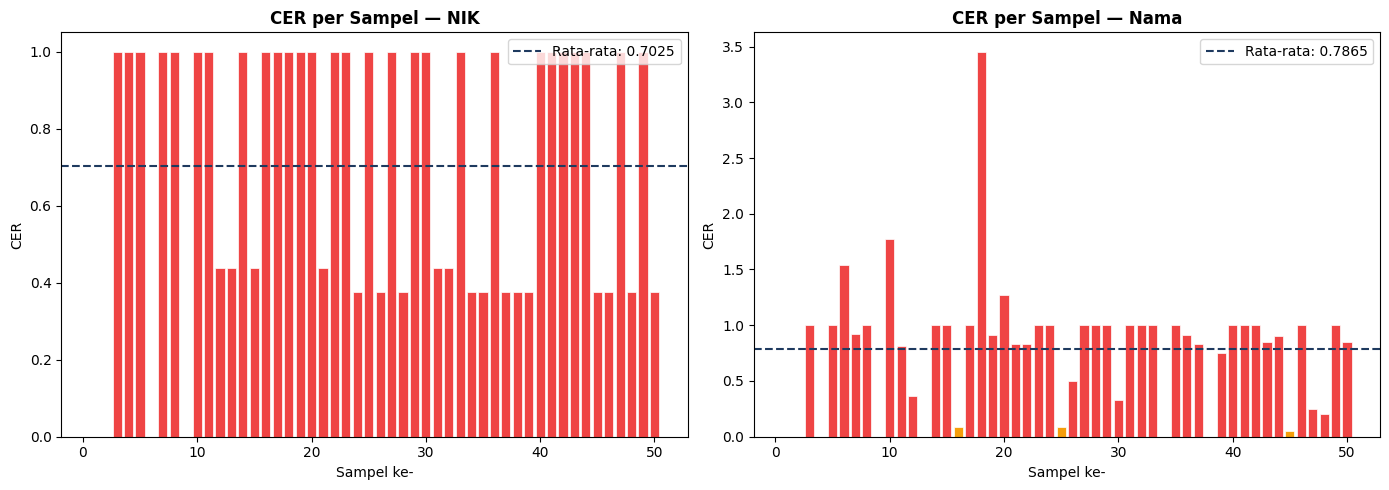


✅ Grafik disimpan ke: /content/drive/MyDrive/ktp_data/grafik_cer_bab4.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Warna: hijau=sempurna, kuning=minor, merah=major
def cer_colors(values):
    return ['#10b981' if v==0 else '#f59e0b' if v<0.2 else '#ef4444' for v in values]

# Grafik CER NIK
axes[0].bar(df_eval['No'], df_eval['CER NIK'], color=cer_colors(df_eval['CER NIK']), edgecolor='white', lw=0.5)
axes[0].axhline(y=avg_cer_nik, color='#1e3a5f', ls='--', lw=1.5, label=f'Rata-rata: {avg_cer_nik:.4f}')
axes[0].set_title('CER per Sampel \u2014 NIK', fontweight='bold')
axes[0].set_xlabel('Sampel ke-')
axes[0].set_ylabel('CER')
axes[0].legend()

# Grafik CER Nama
axes[1].bar(df_eval['No'], df_eval['CER Nama'], color=cer_colors(df_eval['CER Nama']), edgecolor='white', lw=0.5)
axes[1].axhline(y=avg_cer_nama, color='#1e3a5f', ls='--', lw=1.5, label=f'Rata-rata: {avg_cer_nama:.4f}')
axes[1].set_title('CER per Sampel \u2014 Nama', fontweight='bold')
axes[1].set_xlabel('Sampel ke-')
axes[1].set_ylabel('CER')
axes[1].legend()

plt.tight_layout()
chart_path = os.path.join(BASE_DIR, 'grafik_cer_bab4.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n\u2705 Grafik disimpan ke: {chart_path}')